In [60]:
import cv2
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import PIL
import requests
import IPython
from fastai.vision.all import *

In [2]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


## Завантаження датасету

In [3]:
path=untar_data(URLs.DOGS)
path

<div><progress max="839285364" value="839286784"></progress> 100.00% [839286784/839285364 00:17&lt;00:00]</div>

Path('/root/.fastai/data/dogscats')

In [14]:
data_dir = Path(os.path.join(path, 'train'))
data_dir

Path('/root/.fastai/data/dogscats/train')

## Огляд датасету

In [15]:
types = ('*/*.jpg','*/*.jpeg','*/*.png')
img_grabbed = []
for files in types:
    img_grabbed.extend(data_dir.glob(files))
len(img_grabbed)

23000

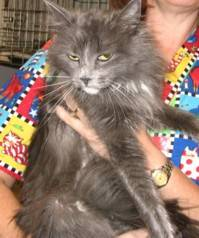

In [16]:
cats = list(data_dir.glob('cats/*'))
PIL.Image.open(str(cats[-1]))

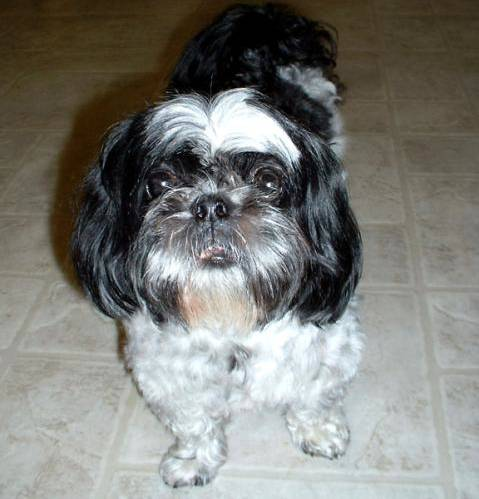

In [17]:
dogs = list(data_dir.glob('dogs/*'))
PIL.Image.open(str(dogs[-1]))

#### Видалення частини набору даних (для коректної роботи google colab)

In [18]:
# google colab session crash fix
print('Original size')
orig_len = len(cats)
print(len(cats))
print(len(dogs))
print()

v = 1.2
new_len_cats=int(len(cats)/v)
new_len_dogs=int(len(dogs)/v)
print('Shrinked size')
print(new_len_cats)
print(new_len_dogs)

Original size
11500
11500

Shrinked size
9583
9583


In [19]:
for i in range(new_len_cats, orig_len):
  os.remove(str(dogs[i]))
  os.remove(str(cats[i]))

In [20]:
cats=cats[0:new_len_cats]
dogs=dogs[0:new_len_dogs]

print(len(cats))
print(len(dogs))

9583
9583


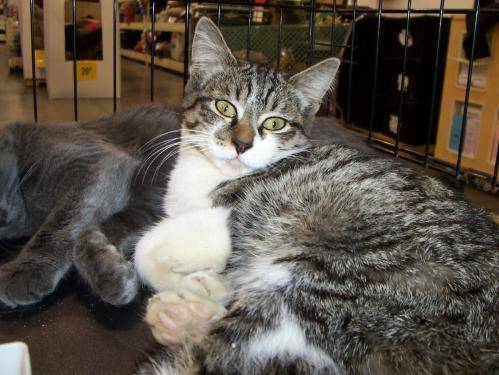

In [21]:
PIL.Image.open(str(cats[-1]))

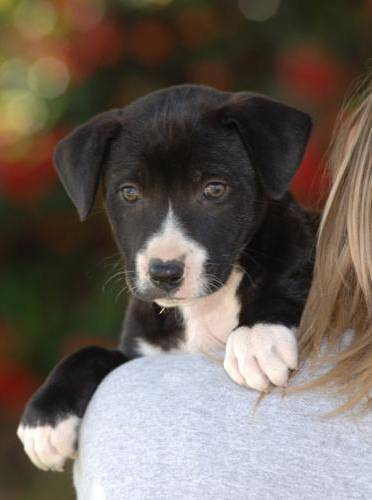

In [22]:
PIL.Image.open(str(dogs[-1]))

## Підготовка даних

In [23]:
batch_size = 32
img_height = 180
img_width = 180

In [24]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 19166 files belonging to 2 classes.
Using 15333 files for training.


In [25]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 19166 files belonging to 2 classes.
Using 3833 files for validation.


In [26]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

['cats', 'dogs']


In [27]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [28]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Створення моделі

In [32]:
model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name='outputs')
])

In [33]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,898 (15.22 MB)

 Trainable params: 3,988,898 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.6311 - loss: 0.6358 - val_accuracy: 0.7169 - val_loss: 0.5623
Epoch 2/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7513 - loss: 0.5055 - val_accuracy: 0.7555 - val_loss: 0.5027
Epoch 3/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8032 - loss: 0.4245 - val_accuracy: 0.7866 - val_loss: 0.4532
Epoch 4/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8408 - loss: 0.3544 - val_accuracy: 0.8072 - val_loss: 0.4618
Epoch 5/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8792 - loss: 0.2789 - val_accuracy: 0.8077 - val_loss: 0.4561
Epoch 6/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9202 - loss: 0.1949 - val_accuracy: 0.7955 - val_loss: 0.4949
Epoch 7/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9525 - loss: 0.1253 - val_accuracy: 0.8145 - val_loss: 0.6253
Epoch 8/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9723 - loss: 0.0766 - val_

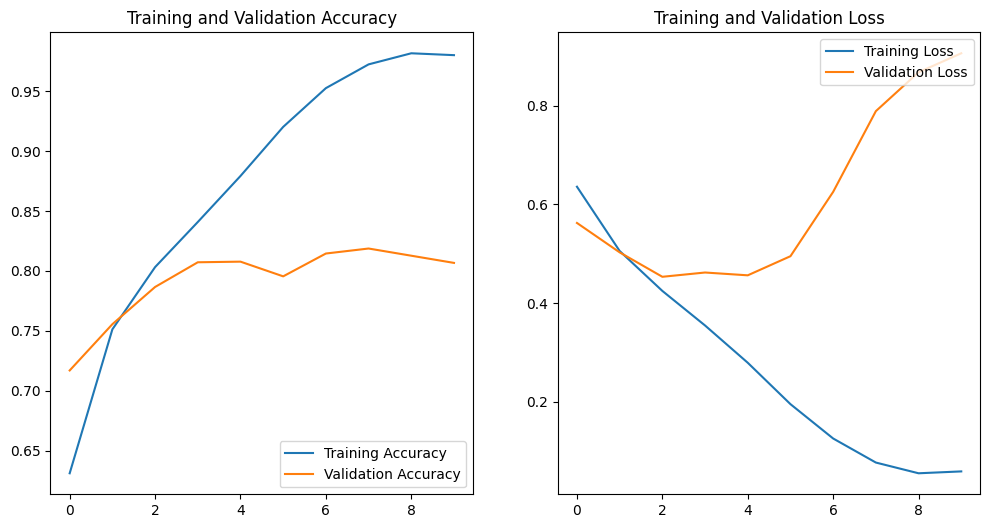

In [39]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Огляд на деяких тестових даних

In [41]:
valid_dir = Path(os.path.join(path, 'valid'))
valid_dir

Path('/root/.fastai/data/dogscats/valid')

In [43]:
img_grabbed = []
for files in types:
    img_grabbed.extend(valid_dir.glob(files))
len(img_grabbed)

2000

In [54]:
cats_test = list(valid_dir.glob('cats/*'))
dogs_test = list(valid_dir.glob('dogs/*'))

In [51]:
def classify_image(img_path):
  img = tf.keras.utils.load_img(
    img_path, target_size=(img_height, img_width)
  )
  img_array = tf.keras.utils.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)

  predictions = model.predict(img_array)
  score = tf.nn.softmax(predictions[0])
  print(
    "This is '{}' with a {:.2f}% confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
  )
  return

In [55]:
for i in range(5):
  PIL.Image.open(str(cats_test[i]))
  classify_image(cats_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
This is 'cats' with a 69.27% confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
This is 'cats' with a 100.00% confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
This is 'cats' with a 99.98% confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
This is 'cats' with a 100.00% confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
This is 'cats' with a 100.00% confidence.


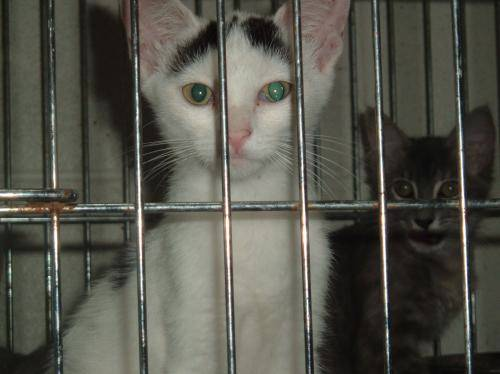

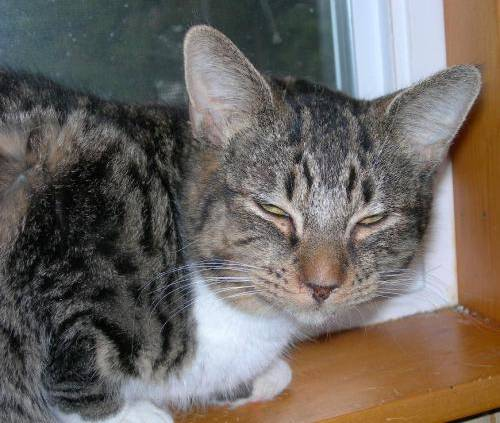

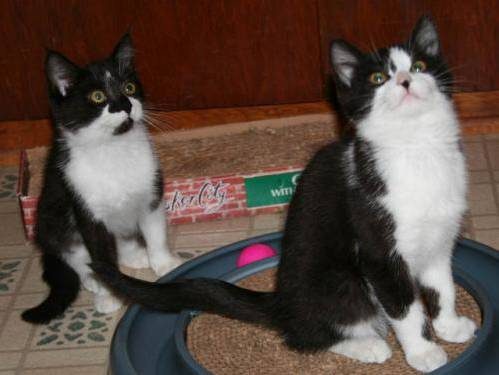

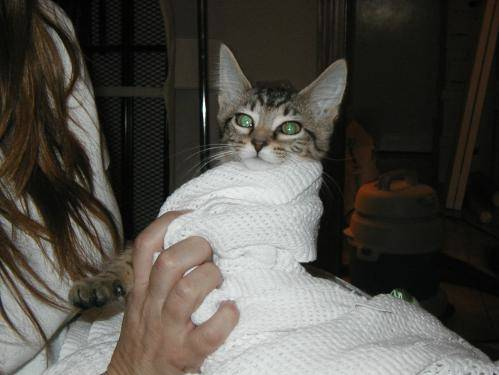

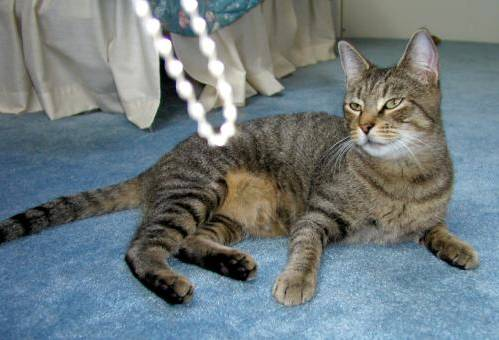

In [61]:
img0 = IPython.display.Image(str(cats_test[0]), width = 140)
img1 = IPython.display.Image(str(cats_test[1]), width = 140)
img2 = IPython.display.Image(str(cats_test[2]), width = 140)
img3 = IPython.display.Image(str(cats_test[3]), width = 140)
img4 = IPython.display.Image(str(cats_test[4]), width = 140)
display(img0,img1,img2,img3,img4)

In [56]:
for i in range(5):
  PIL.Image.open(str(dogs_test[i]))
  classify_image(dogs_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
This is 'dogs' with a 89.47% confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
This is 'dogs' with a 81.83% confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
This is 'cats' with a 99.60% confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
This is 'dogs' with a 99.71% confidence.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
This is 'dogs' with a 98.51% confidence.


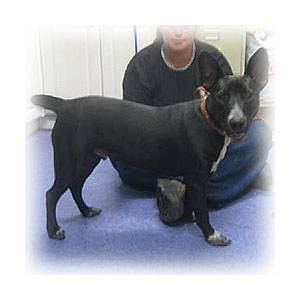

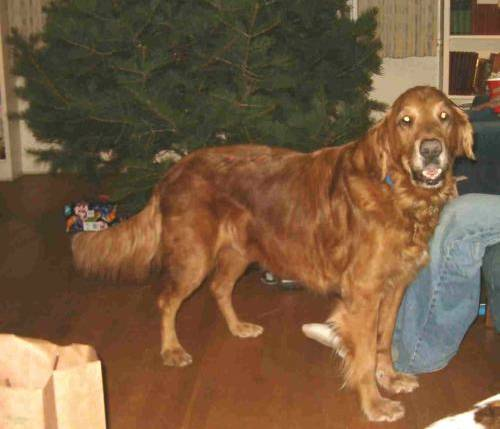

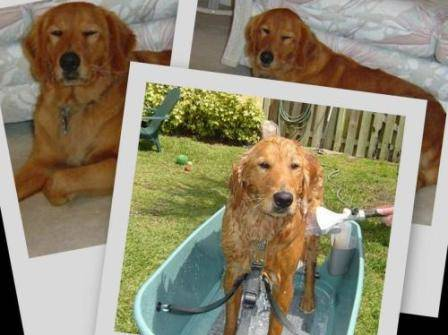

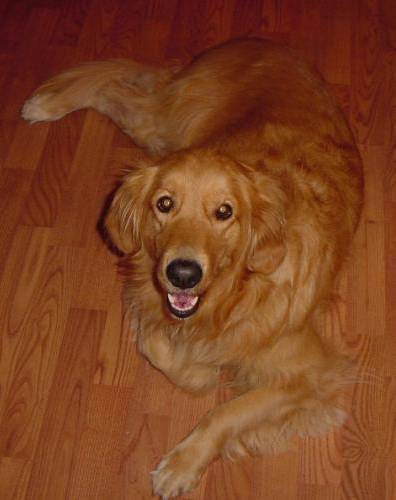

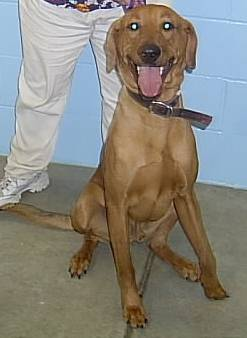

In [62]:
img0 = IPython.display.Image(str(dogs_test[0]), width = 140)
img1 = IPython.display.Image(str(dogs_test[1]), width = 140)
img2 = IPython.display.Image(str(dogs_test[2]), width = 140)
img3 = IPython.display.Image(str(dogs_test[3]), width = 140)
img4 = IPython.display.Image(str(dogs_test[4]), width = 140)
display(img0,img1,img2,img3,img4)

In [68]:
model.save('model.h5')